# MinneApple: detección, segmentación y atención para estimar la cosecha
**Notebook de sustentación** · Proyecto 2 de Visión Computacional con Deep Learning (UAO) · 3 de octubre de 2026

Este cuaderno recorre el proyecto en el orden de la sustentación. **No entrena nada**: importa las funciones del repositorio y lee las cifras ya calculadas de `reports/` y `runs/`; las tablas se generan desde esos archivos, no se escriben a mano.
Necesita los datos descargados y preparados (README: «Datos» y «Comandos en orden»).

> **Reproducibilidad — qué hace falta para correr este cuaderno (no solo leerlo):**
> 1. **Los datos preparados** (`data/yolo/`, `data/splits.csv`): públicos, se reconstruyen con los comandos 1-2 del README a partir de MinneApple (~15-20 min, sin GPU).
> 2. **Solo 3 corridas entrenadas, ~32 MB en total** (no las 11 que hay en `runs/`): `runs/colab_1280_small_s0/` (modelo final), `runs/c2psa_s0/` y `runs/sin_c2psa_s0/` (para la sección c y la tabla de la ablación de la sección d). El resto de `reports/` **ya está en git** (61 archivos, todas las cifras de `evaluar.py`, el bootstrap, INT8 y tiempos): esas secciones (a, d, f) solo leen JSON/CSV y no necesitan ningún peso.
> Los pesos no van en git (son binarios grandes). Sin ellos, `jupyter nbconvert --execute` falla en las secciones **c** y **e** (las únicas que cargan un modelo); el resto corre igual.

| Sección | Contenido | Estado |
|---|---|---|
| a | Problema y dataset (EDA) | **lista** |
| b | Partición por video y fidelidad de los polígonos | **lista** |
| c | Arquitectura y configuración | **lista** |
| d | Métricas de test y ablación con bootstrap pareado | **lista** (test evaluado una sola vez, 27-sep) |
| e | Aislamiento por instancia y Grad-CAM a mano | **lista** (con el modelo final) |
| f | INT8 frente a FP32 y tiempos CPU frente a GPU | **lista** |

In [1]:
import collections, csv, json, re, sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Markdown, display
from PIL import Image

# Raíz del repositorio: se sube desde el directorio del notebook hasta encontrar README.md y scripts/
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "README.md").exists() and (p / "scripts").exists())
sys.path.insert(0, str(RAIZ / "scripts"))
sys.path.insert(0, str(RAIZ / "app"))
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
print("Repositorio encontrado; carpetas:", sorted(p.name for p in RAIZ.iterdir() if p.is_dir() and not p.name.startswith(".")))

Repositorio encontrado; carpetas: ['app', 'configs', 'data', 'docs', 'graphify-out', 'models', 'notebooks', 'reports', 'runs', 'scripts', 'weights']


## a. Problema y dataset (EDA)
El agricultor necesita estimar el rendimiento del huerto antes de la cosecha; hacerlo a ojo es impreciso. MinneApple aporta fotos de
árboles de manzana con máscara de instancia por manzana. Esta sección lee **solo** `reports/eda.json` (lo escribe
`scripts/preparar_datos.py`; no se recalcula nada aquí) para mostrar tres cosas: la densidad de manzanas por video, el tamaño típico
de una manzana, y cuántas hay por imagen.

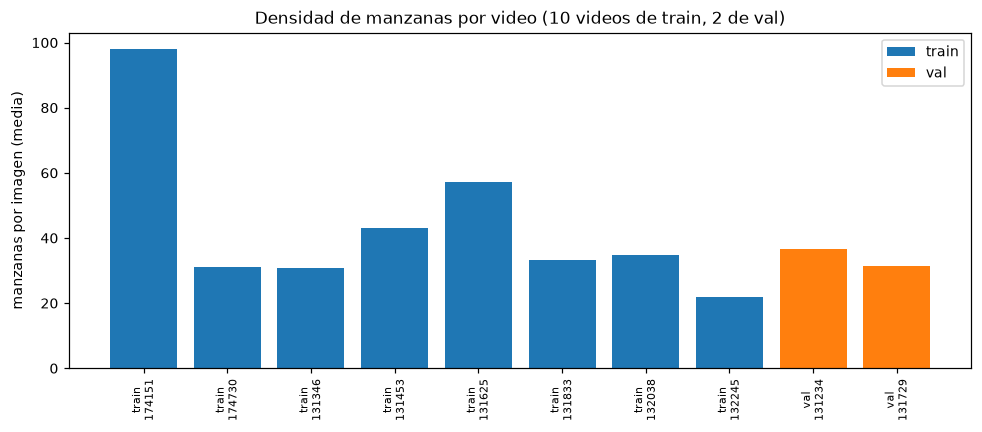

Densidad por video: de 21.9 a 98.1 manzanas/imagen (test, 7 hileras distintas: 37.1 de media).


In [2]:
eda = json.load(open(RAIZ / "reports" / "eda.json", encoding="utf-8"))

fig, ax = plt.subplots(figsize=(9, 4))
for split, color in (("train", "tab:blue"), ("val", "tab:orange")):
    videos = eda[split]["por_video"]
    ax.bar([f"{split}\n{v[-6:]}" for v in videos], [videos[v]["manzanas_por_imagen"] for v in videos], color=color, label=split)
ax.set_ylabel("manzanas por imagen (media)")
ax.set_title("Densidad de manzanas por video (10 videos de train, 2 de val)")
ax.tick_params(axis="x", labelsize=7, rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

todos = [v["manzanas_por_imagen"] for s in ("train", "val") for v in eda[s]["por_video"].values()]
print(f"Densidad por video: de {min(todos):.1f} a {max(todos):.1f} manzanas/imagen "
      f"(test, 7 hileras distintas: {eda['test']['manzanas_por_imagen']['media']} de media).")

In [3]:
lineas = ["| Partición | Lado mediano (px) | < 32×32 px | Área mediana (px²) |", "|---|---|---|---|"]
for split in ("train", "val", "test"):
    e = eda[split]
    lineas.append(f"| {split} | {e['lado_mayor_px_mediana']:.0f} | {e['frac_pequenas_coco_lt_32x32']:.0%} | {e['area_px']['mediana']:.0f} |")
display(Markdown("\n".join(lineas)))
print("Las manzanas son objetos pequeños: la mayoría mide menos que una casilla de 32×32 px en una imagen de 1280×720.")

| Partición | Lado mediano (px) | < 32×32 px | Área mediana (px²) |
|---|---|---|---|
| train | 30 | 88% | 488 |
| val | 32 | 86% | 526 |
| test | 35 | 75% | 611 |

Las manzanas son objetos pequeños: la mayoría mide menos que una casilla de 32×32 px en una imagen de 1280×720.


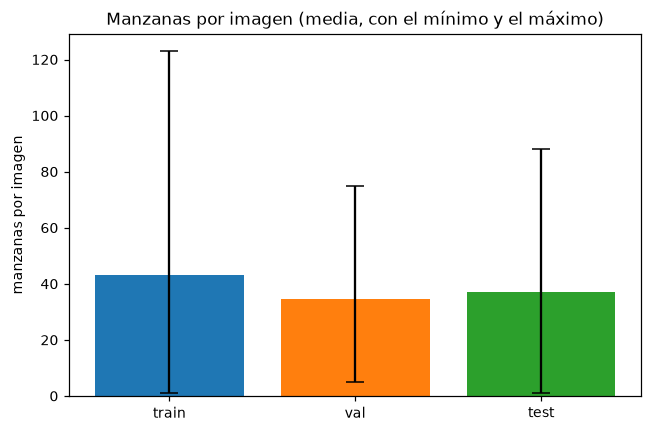

train: media 43.3, entre 1 y 123 manzanas por imagen (577 imágenes, 24958 manzanas)
val: media 34.6, entre 5 y 75 manzanas por imagen (93 imágenes, 3221 manzanas)
test: media 37.1, entre 1 y 88 manzanas por imagen (331 imágenes, 12285 manzanas)


In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
particiones = ("train", "val", "test")
medias = [eda[s]["manzanas_por_imagen"]["media"] for s in particiones]
minimos = [eda[s]["manzanas_por_imagen"]["min"] for s in particiones]
maximos = [eda[s]["manzanas_por_imagen"]["max"] for s in particiones]
ax.bar(particiones, medias, yerr=[[m - mi for m, mi in zip(medias, minimos)], [ma - m for m, ma in zip(medias, maximos)]],
       capsize=6, color=["tab:blue", "tab:orange", "tab:green"])
ax.set_ylabel("manzanas por imagen")
ax.set_title("Manzanas por imagen (media, con el mínimo y el máximo)")
plt.tight_layout()
plt.show()
for s in particiones:
    e = eda[s]["manzanas_por_imagen"]
    print(f"{s}: media {e['media']}, entre {e['min']} y {e['max']} manzanas por imagen ({eda[s]['imagenes']} imágenes, {eda[s]['manzanas']} manzanas)")

## b. Partición por video y su verificación
MinneApple trae 670 imágenes de entrenamiento que salen de **10 videos** (el prefijo `AAAAMMDD_hhmmss` del nombre) y 331 de test, de otras hileras y de otro año. Los fotogramas de un mismo video son casi iguales, así que partir por imagen filtraría información de entrenamiento a validación:
**se parte por video completo** y se comprueba por código. El test oficial (331 imágenes) es el publicado por los autores en 2022,
de otras hileras y otro año que train: es más creíble que un test recortado del propio train y permite comparar con la cifra del
artículo original. Se usa una sola vez, al final.

In [5]:
# Lee data/splits.csv (lo escribe scripts/preparar_datos.py) y verifica que ningún video cae en dos particiones
filas = list(csv.DictReader(open(RAIZ / "data" / "splits.csv", encoding="utf-8")))
por_grupo = collections.defaultdict(collections.Counter)
for f in filas:
    por_grupo[f["grupo"]][f["particion"]] += 1
compartidos = {g: dict(c) for g, c in por_grupo.items() if len(c) > 1}
assert not compartidos, f"videos en más de una partición: {compartidos}"

lineas = ["| Video (grupo) | Partición | Imágenes |", "|---|---|---|"]
for g in sorted(por_grupo):
    ((particion, n),) = por_grupo[g].items()
    lineas.append(f"| `{g}` | {particion} | {n} |")
display(Markdown("\n".join(lineas)))
totales = collections.Counter(f["particion"] for f in filas)
print(f"OK: {len(por_grupo)} videos o grupos y ninguno en dos particiones. Imágenes: " + ", ".join(f"{p} {n}" for p, n in totales.items()))

| Video (grupo) | Partición | Imágenes |
|---|---|---|
| `20150919_174151` | train | 66 |
| `20150919_174730` | train | 100 |
| `20150921_131234` | val | 59 |
| `20150921_131346` | train | 88 |
| `20150921_131453` | train | 81 |
| `20150921_131625` | train | 52 |
| `20150921_131729` | val | 34 |
| `20150921_131833` | train | 84 |
| `20150921_132038` | train | 83 |
| `20150921_132245` | train | 23 |
| `dataset1_back` | test | 40 |
| `dataset1_front` | test | 54 |
| `dataset2_back` | test | 51 |
| `dataset2_front` | test | 51 |
| `dataset3_back` | test | 45 |
| `dataset3_front` | test | 48 |
| `dataset4_front` | test | 42 |

OK: 17 videos o grupos y ninguno en dos particiones. Imágenes: train 577, val 93, test 331


In [6]:
# Fidelidad de la conversión máscara -> polígono: IoU entre la máscara original y el polígono rasterizado (calculado por scripts/preparar_datos.py)
eda = json.load(open(RAIZ / "reports" / "eda.json", encoding="utf-8"))
lineas = ["| Partición | Manzanas | IoU medio polígono frente a máscara | IoU mínimo | Instancias partidas | Sin polígono |", "|---|---|---|---|---|---|"]
for p in ("train", "val", "test"):
    e = eda[p]
    i = e["iou_poligono_vs_mascara"]
    lineas.append(f"| {p} | {e['manzanas']:,} | {i['media']:.4f} | {i['min']:.4f} | {e['frac_instancias_partidas']:.1%} | {e['descartadas_sin_poligono']} |")
display(Markdown("\n".join(lineas)))

| Partición | Manzanas | IoU medio polígono frente a máscara | IoU mínimo | Instancias partidas | Sin polígono |
|---|---|---|---|---|---|
| train | 24,958 | 1.0000 | 0.9997 | 0.0% | 3 |
| val | 3,221 | 0.9998 | 0.9953 | 0.1% | 1 |
| test | 12,285 | 1.0000 | 0.9918 | 0.1% | 0 |

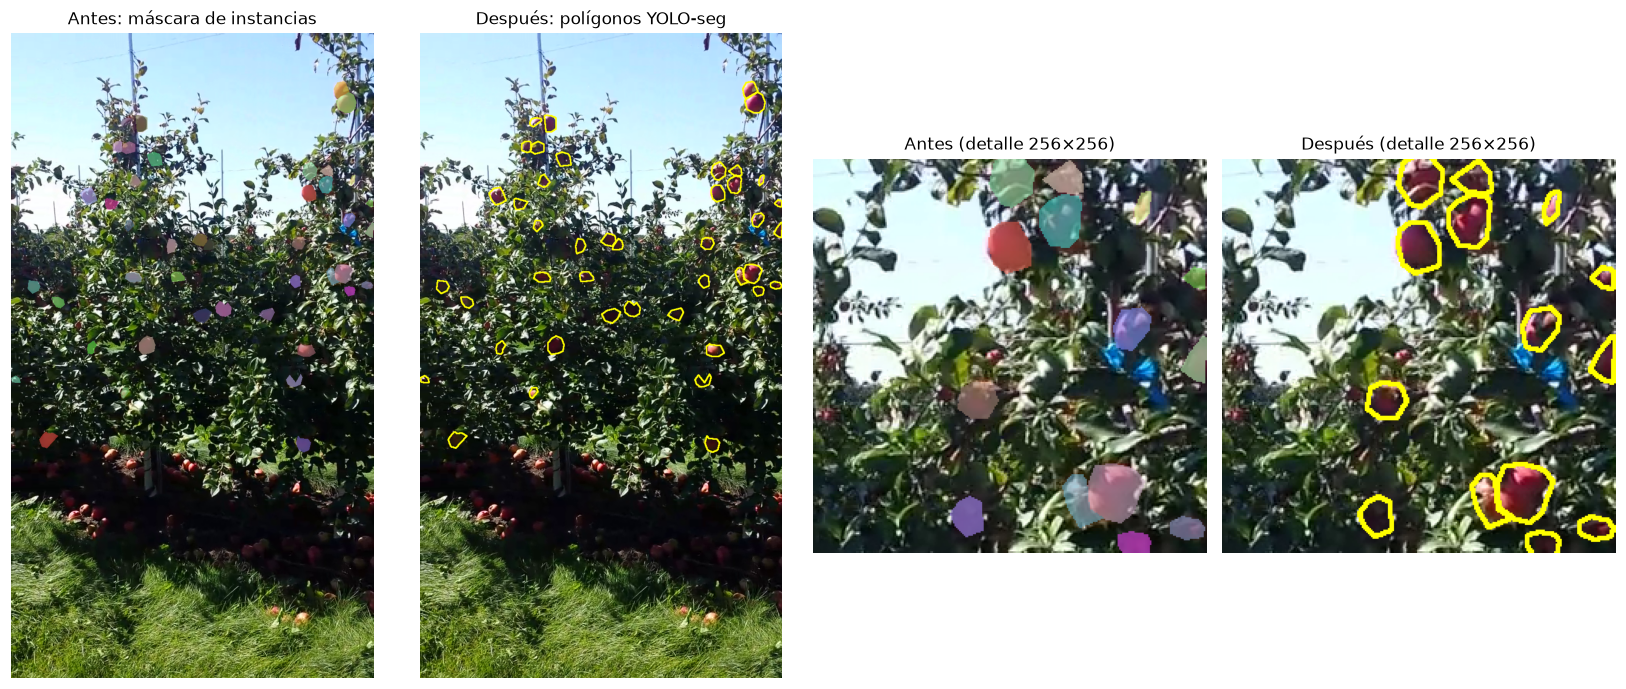

20150921_131234_image201.png: 43 manzanas · IoU polígonos frente a máscara en esta imagen: 1.0000


In [7]:
# Antes y después con una imagen real de validación: máscara de instancias original frente a los polígonos YOLO-seg
from preparar_datos import mask_to_polygons, polygon_iou

ruta = sorted((RAIZ / "data" / "yolo" / "images" / "val").glob("*.png"))[3]
img = cv2.cvtColor(cv2.imread(str(ruta)), cv2.COLOR_BGR2RGB)
mask = np.array(Image.open(RAIZ / "data" / "raw" / "detection" / "train" / "masks" / ruta.name))
polys, _ = mask_to_polygons(mask)
h, w = mask.shape

colores = np.random.default_rng(0).integers(60, 255, (int(mask.max()) + 1, 3))
antes = img.copy()
m = mask > 0
antes[m] = (0.4 * img[m] + 0.6 * colores[mask[m]]).astype(np.uint8)
despues = img.copy()
for p in polys:
    cv2.polylines(despues, [np.round(p * [w, h]).astype(np.int32)], True, (255, 255, 0), 2)

# ventana de 256x256 con más manzana, para ver el detalle
k = 256
s = cv2.integral(m.astype(np.uint8))
suma = s[k:, k:] - s[:-k, k:] - s[k:, :-k] + s[:-k, :-k]
y0, x0 = np.unravel_index(suma.argmax(), suma.shape)

fig, ax = plt.subplots(1, 4, figsize=(15, 6.2))
for a, im, t in zip(ax, (antes, despues, antes[y0:y0 + k, x0:x0 + k], despues[y0:y0 + k, x0:x0 + k]),
                    ("Antes: máscara de instancias", "Después: polígonos YOLO-seg", "Antes (detalle 256×256)", "Después (detalle 256×256)")):
    a.imshow(im)
    a.set_title(t)
    a.axis("off")
plt.tight_layout()
plt.show()
print(f"{ruta.name}: {len(polys)} manzanas · IoU polígonos frente a máscara en esta imagen: {polygon_iou(mask, polys):.4f}")

## c. Arquitectura y configuración
Un solo modelo, **YOLO11n-seg**, hace detección (cajas) y segmentación de instancias (máscaras) a la vez. El bloque de **self-attention** es **C2PSA** (capa 10, al final del backbone, sobre el mapa de paso 32). La ablación compara el modelo completo con una variante idéntica en la que esa capa se reemplaza por `nn.Identity`:
mismos índices de capa, mismos pesos iniciales COCO, misma semilla y mismos datos.

**Modelo final:** YOLO11**s**-seg a 1280 px (elegido sobre nano por un mAP de caja 0,020 mayor en validación, confirmado con 2 semillas), misma arquitectura con más canales; esta sección muestra **nano**, la variante con la que se hizo la ablación con y sin C2PSA.

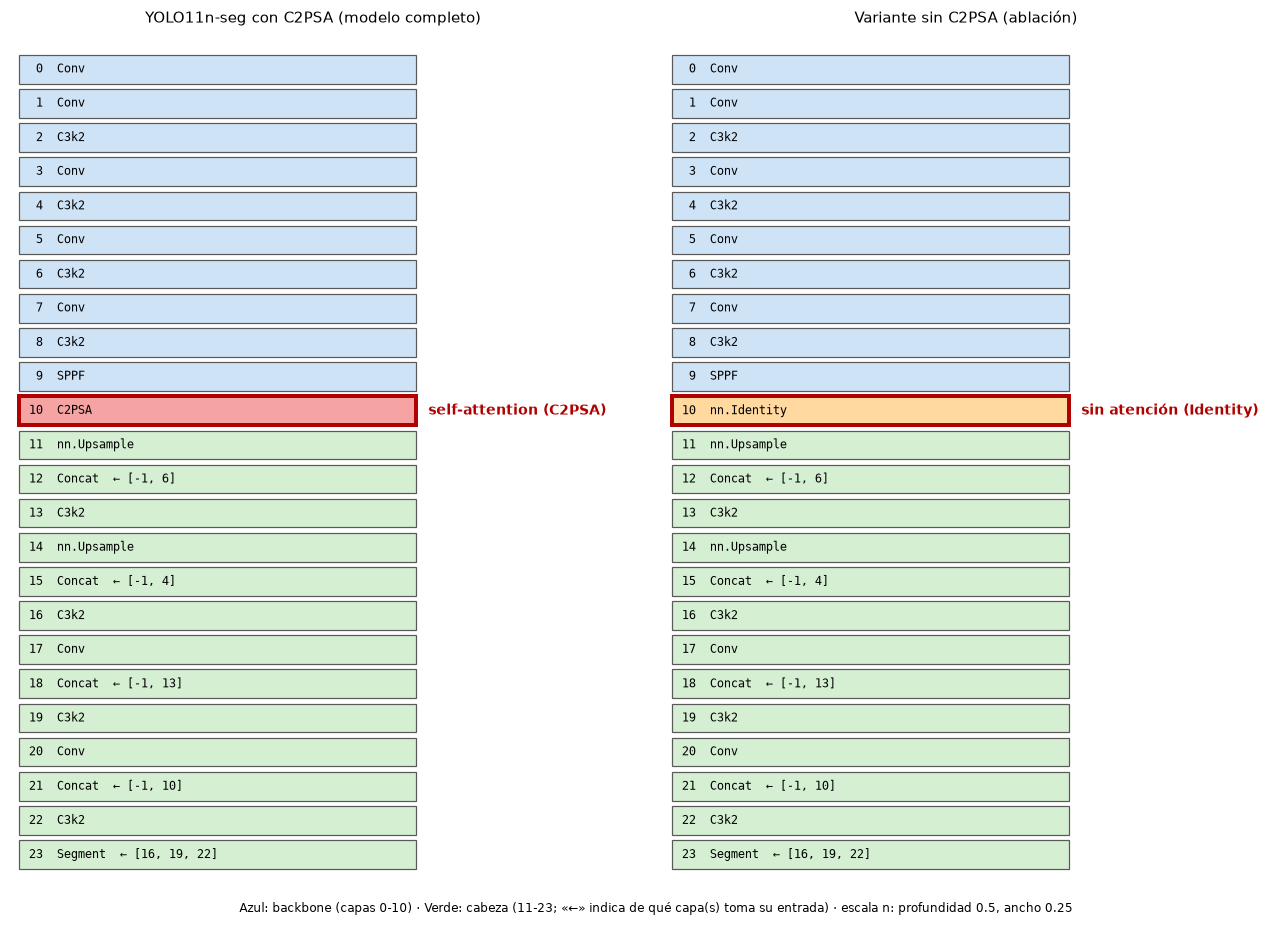

Las dos variantes difieren solo en la capa 10.


In [8]:
# Esquema dibujado desde los YAML (no es una imagen pegada): la capa 10 resaltada es la real
import ultralytics

BASE = Path(ultralytics.__file__).parent / "cfg" / "models" / "11" / "yolo11-seg.yaml"
SIN = RAIZ / "configs" / "yolo11n-seg-sin-c2psa.yaml"

def leer_capas(ruta):
    y = yaml.safe_load(open(ruta, encoding="utf-8"))
    return y["backbone"] + y["head"], y["scales"]["n"]

def dibujar(ax, lista, titulo):
    n = len(lista)
    for i, (origen, rep, modulo, args) in enumerate(lista):
        y = n - i
        color = "#cfe3f7" if i <= 10 else "#d5efd3"  # backbone azul, cabeza verde
        borde, ancho = "0.35", 0.8
        if i == 10:  # la capa que cambia en la ablación
            color, borde, ancho = ("#f5a3a3" if modulo == "C2PSA" else "#ffd9a0"), "#b00000", 2.6
        ax.add_patch(plt.Rectangle((0, y - 0.42), 10, 0.84, fc=color, ec=borde, lw=ancho))
        desde = "" if origen == -1 else f"  ← {origen}"
        ax.text(0.25, y, f"{i:>2}  {modulo}{desde}", va="center", family="monospace", fontsize=8)
        if i == 10:
            ax.text(10.3, y, "self-attention (C2PSA)" if modulo == "C2PSA" else "sin atención (Identity)", va="center", color="#b00000", fontsize=9, weight="bold")
    ax.set_xlim(-0.2, 15)
    ax.set_ylim(0.3, n + 1.1)
    ax.axis("off")
    ax.set_title(titulo, fontsize=10)

con, escala = leer_capas(BASE)
sin, _ = leer_capas(SIN)
assert con[10][2] == "C2PSA" and sin[10][2] == "nn.Identity" and len(con) == len(sin) == 24
assert [i for i, (a, b) in enumerate(zip(con, sin)) if a != b] == [10], "las variantes deben diferir solo en la capa 10"

fig, ejes = plt.subplots(1, 2, figsize=(12, 8.5))
dibujar(ejes[0], con, "YOLO11n-seg con C2PSA (modelo completo)")
dibujar(ejes[1], sin, "Variante sin C2PSA (ablación)")
fig.text(0.5, 0.02, f"Azul: backbone (capas 0-10) · Verde: cabeza (11-23; «←» indica de qué capa(s) toma su entrada) · escala n: profundidad {escala[0]}, ancho {escala[1]}", ha="center", fontsize=8)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()
print("Las dos variantes difieren solo en la capa 10.")

In [9]:
# model.info() de las dos variantes entrenadas (nc = 1) y cuántos tensores COCO se transfirieron al iniciar el entrenamiento
from ultralytics import YOLO

filas_info = []
for etiqueta, corrida in (("con C2PSA", "c2psa_s0"), ("sin C2PSA (Identity)", "sin_c2psa_s0")):
    n_capas, params, _, gflops = YOLO(str(RAIZ / "runs" / corrida / "weights" / "best.pt")).info(imgsz=1024)
    log = re.sub(r"\x1b\[[0-9;]*[A-Za-z]", "", (RAIZ / "runs" / f"{corrida}.log").read_text(encoding="utf-8", errors="ignore"))
    transferidos = re.findall(r"Transferred (\d+)/(\d+) items", log)[-1]
    filas_info.append((etiqueta, n_capas, params, gflops, transferidos))

lineas = ["| Variante | Capas | Parámetros | GFLOPs a 1024 px | Tensores COCO transferidos |", "|---|---|---|---|---|"]
for e, c, p, g, t in filas_info:
    lineas.append(f"| {e} | {c} | {p:,} | {g:.1f} | {t[0]} de {t[1]} |")
display(Markdown("\n".join(lineas)))
print(f"C2PSA añade {filas_info[0][2] - filas_info[1][2]:,} parámetros ({filas_info[0][2] / filas_info[1][2] - 1:.1%} más) y {filas_info[0][3] - filas_info[1][3]:.1f} GFLOPs.")
sin_coco = [int(r[4][1]) - int(r[4][0]) for r in filas_info]
print(f"Tensores que empiezan sin pesos COCO: {sin_coco[0]} (con C2PSA) y {sin_coco[1]} (sin C2PSA): son los que dependen del número de clases (la cabeza pasa de 80 clases a 1, `apple`).")
print(f"El modelo sin C2PSA tiene {int(filas_info[0][4][1]) - int(filas_info[1][4][1])} tensores menos: los de la capa 10.")

YOLO11n-seg summary: 203 layers, 2,842,803 parameters, 0 gradients, 25.3 GFLOPs


YOLO11n-seg-sin-c2psa summary: 186 layers, 2,593,075 parameters, 0 gradients, 24.4 GFLOPs


| Variante | Capas | Parámetros | GFLOPs a 1024 px | Tensores COCO transferidos |
|---|---|---|---|---|
| con C2PSA | 203 | 2,842,803 | 25.3 | 510 de 561 |
| sin C2PSA (Identity) | 186 | 2,593,075 | 24.4 | 468 de 519 |

C2PSA añade 249,728 parámetros (9.6% más) y 0.9 GFLOPs.
Tensores que empiezan sin pesos COCO: 51 (con C2PSA) y 51 (sin C2PSA): son los que dependen del número de clases (la cabeza pasa de 80 clases a 1, `apple`).
El modelo sin C2PSA tiene 42 tensores menos: los de la capa 10.


### Hiperparámetros y aumentaciones
Tabla **generada leyendo `runs/c2psa_s0/args.yaml`** (la configuración real de la corrida) y el registro de entrenamiento para el optimizador efectivo. La columna «Por qué» trae la razón de cada valor; los que no tienen una razón específica escrita
son **predeterminados de Ultralytics**, sin ajustar uno por uno para este dataset.

In [10]:
args = yaml.safe_load(open(RAIZ / "runs" / "c2psa_s0" / "args.yaml", encoding="utf-8"))
log = re.sub(r"\x1b\[[0-9;]*[A-Za-z]", "", (RAIZ / "runs" / "c2psa_s0.log").read_text(encoding="utf-8", errors="ignore"))
m_opt = re.search(r"optimizer: (\w+\([^)]*\))", log)
efectivo = m_opt.group(1) if m_opt else "no disponible en el registro"
ignora_lr0 = "ignoring \'lr0=" in log

# Por qué de cada parámetro, escrito aquí mismo (no en un archivo aparte): 1024 px es la resolución más rápida que cabe en la
# GPU de 4 GB sin desbordar a la RAM (1280 con lote 4 tardaba 14 min/época; 1024 con mask_ratio=8, ~5,6 min); sin parada temprana
# para que las 6 corridas de la ablación entrenen las mismas épocas y sean comparables; los aumentos son los predeterminados de
# Ultralytics 8.4.149, sin ajustar a mano para este dataset (comprobado en runs/c2psa_s0/args.yaml y en el código de la librería).
RAZON = {
    "epochs": "40 épocas, fijadas antes de ver resultados junto con el resto de la configuración",
    "imgsz": "1024 px: la resolución más rápida que cabe en la GPU de 4 GB sin desbordar a la RAM",
    "batch": "lote 4: el mayor que cupo en la GPU de 4 GB sin desbordar a la RAM del sistema",
    "seed": "una semilla distinta por corrida (0, 1, 2), para promediar y medir la variación entre semillas",
    "patience": "sin parada temprana, para que las 6 corridas de la ablación entrenen las mismas épocas y sean comparables",
    "cache": "no se usa cache=ram: Ultralytics avisa que no es determinista con ese modo",
    "mask_ratio": "8 en el entrenamiento, para que la máscara no desborde memoria (hasta 123 manzanas por imagen); las métricas finales se recalculan con mask_ratio=1, más preciso",
    "hsv_h": "±2,7 de 180 (≈5°): predeterminado; demasiado pequeño para convertir un rojo en verde",
    "hsv_s": "multiplicador en [0,3, 1,7]: predeterminado; no se evaluó su efecto, y es el que más podría chocar con distinguir manzanas rojas de verdes",
    "hsv_v": "multiplicador en [0,6, 1,4]: predeterminado; los datos ya incluyen el lado soleado y el sombreado de las hileras",
    "degrees": "0 (apagado): predeterminado de Ultralytics",
    "translate": "10 %: predeterminado; hace que las manzanas aparezcan en cualquier parte del encuadre",
    "scale": "factor aleatorio en [0,5, 1,5]: predeterminado; simula la distancia a la cámara, aunque con manzanas ya pequeñas (75-89 % < 32×32 px) achicarlas más es un riesgo no evaluado",
    "shear": "0 (apagado): predeterminado de Ultralytics",
    "perspective": "0 (apagado): predeterminado de Ultralytics",
    "flipud": "0 (apagado): la gravedad da un «arriba»; manzanas y hojas no aparecen invertidas",
    "fliplr": "50 %: el huerto es simétrico izquierda-derecha",
    "mosaic": "activo, se apaga en la época 30: más variedad de fondos y densidad de manzanas por lote; las últimas 10 épocas ven imágenes naturales",
    "mixup": "0 (apagado): predeterminado de Ultralytics",
    "cutmix": "0 (apagado): predeterminado de Ultralytics",
    "copy_paste": "0 (apagado): predeterminado de Ultralytics",
    "close_mosaic": "10 (últimas 10 épocas sin mosaico): ver «mosaic»",
    "erasing": "0,4 en args.yaml, pero **no se aplica**: solo se usa en clasificación, no en segmentación",
    "auto_augment": "randaugment en args.yaml, pero **no se aplica**: igual que «erasing», solo es para clasificación",
    "bgr": "0 (apagado): predeterminado de Ultralytics",
}
FIJADO_EN_SCRIPT = ("deterministic", "max_det")  # scripts/entrenar.py los fija; coinciden con el predeterminado
SOLO_CLASIFICACION = ("erasing", "auto_augment")  # comprobado en el código de Ultralytics: classify_augmentations
GRUPOS = [("Entrenamiento", ["epochs", "imgsz", "batch", "seed", "deterministic", "patience", "cache", "mask_ratio", "max_det", "amp"]),
          ("Optimizador", ["optimizer", "lr0", "lrf", "momentum", "weight_decay", "warmup_epochs", "cos_lr"]),
          ("Aumentaciones", ["hsv_h", "hsv_s", "hsv_v", "degrees", "translate", "scale", "shear", "perspective", "flipud", "fliplr",
                             "mosaic", "mixup", "cutmix", "copy_paste", "close_mosaic", "erasing", "auto_augment", "bgr"])]

lineas = ["| Grupo | Parámetro | Valor en args.yaml | ¿Se aplica? | Por qué |", "|---|---|---|---|---|"]
sin_razon = []
for grupo, claves in GRUPOS:
    for k in claves:
        if k not in args:
            continue
        aplica = ""
        if k in SOLO_CLASIFICACION:
            aplica = "no: solo clasificación"
        elif k == "optimizer" and args[k] == "auto":
            aplica = f"efectivo: `{efectivo}`"
        elif k in ("lr0", "momentum") and ignora_lr0 and args.get("optimizer") == "auto":
            aplica = "ignorado por optimizer=auto"
        por_que = RAZON.get(k)
        if not por_que:
            if k in FIJADO_EN_SCRIPT:
                por_que = "fijado en `scripts/entrenar.py` (coincide con el predeterminado)"
            else:
                por_que = "predeterminado de Ultralytics"
                sin_razon.append(k)
        lineas.append(f"| {grupo} | `{k}` | `{args[k]}` | {aplica} | {por_que} |")
display(Markdown("\n".join(lineas)))
print(f"{len(lineas) - 2} parámetros leídos de runs/c2psa_s0/args.yaml.")
print("Sin razón específica escrita (valor predeterminado de Ultralytics, sin más detalle):", ", ".join(sin_razon))


| Grupo | Parámetro | Valor en args.yaml | ¿Se aplica? | Por qué |
|---|---|---|---|---|
| Entrenamiento | `epochs` | `40` |  | 40 épocas, fijadas antes de ver resultados junto con el resto de la configuración |
| Entrenamiento | `imgsz` | `1024` |  | 1024 px: la resolución más rápida que cabe en la GPU de 4 GB sin desbordar a la RAM |
| Entrenamiento | `batch` | `4` |  | lote 4: el mayor que cupo en la GPU de 4 GB sin desbordar a la RAM del sistema |
| Entrenamiento | `seed` | `0` |  | una semilla distinta por corrida (0, 1, 2), para promediar y medir la variación entre semillas |
| Entrenamiento | `deterministic` | `True` |  | fijado en `scripts/entrenar.py` (coincide con el predeterminado) |
| Entrenamiento | `patience` | `0` |  | sin parada temprana, para que las 6 corridas de la ablación entrenen las mismas épocas y sean comparables |
| Entrenamiento | `cache` | `disk` |  | no se usa cache=ram: Ultralytics avisa que no es determinista con ese modo |
| Entrenamiento | `mask_ratio` | `8` |  | 8 en el entrenamiento, para que la máscara no desborde memoria (hasta 123 manzanas por imagen); las métricas finales se recalculan con mask_ratio=1, más preciso |
| Entrenamiento | `max_det` | `300` |  | fijado en `scripts/entrenar.py` (coincide con el predeterminado) |
| Entrenamiento | `amp` | `True` |  | predeterminado de Ultralytics |
| Optimizador | `optimizer` | `auto` | efectivo: `AdamW(lr=0.002, momentum=0.9)` | predeterminado de Ultralytics |
| Optimizador | `lr0` | `0.01` | ignorado por optimizer=auto | predeterminado de Ultralytics |
| Optimizador | `lrf` | `0.01` |  | predeterminado de Ultralytics |
| Optimizador | `momentum` | `0.937` | ignorado por optimizer=auto | predeterminado de Ultralytics |
| Optimizador | `weight_decay` | `0.0005` |  | predeterminado de Ultralytics |
| Optimizador | `warmup_epochs` | `3.0` |  | predeterminado de Ultralytics |
| Optimizador | `cos_lr` | `False` |  | predeterminado de Ultralytics |
| Aumentaciones | `hsv_h` | `0.015` |  | ±2,7 de 180 (≈5°): predeterminado; demasiado pequeño para convertir un rojo en verde |
| Aumentaciones | `hsv_s` | `0.7` |  | multiplicador en [0,3, 1,7]: predeterminado; no se evaluó su efecto, y es el que más podría chocar con distinguir manzanas rojas de verdes |
| Aumentaciones | `hsv_v` | `0.4` |  | multiplicador en [0,6, 1,4]: predeterminado; los datos ya incluyen el lado soleado y el sombreado de las hileras |
| Aumentaciones | `degrees` | `0.0` |  | 0 (apagado): predeterminado de Ultralytics |
| Aumentaciones | `translate` | `0.1` |  | 10 %: predeterminado; hace que las manzanas aparezcan en cualquier parte del encuadre |
| Aumentaciones | `scale` | `0.5` |  | factor aleatorio en [0,5, 1,5]: predeterminado; simula la distancia a la cámara, aunque con manzanas ya pequeñas (75-89 % < 32×32 px) achicarlas más es un riesgo no evaluado |
| Aumentaciones | `shear` | `0.0` |  | 0 (apagado): predeterminado de Ultralytics |
| Aumentaciones | `perspective` | `0.0` |  | 0 (apagado): predeterminado de Ultralytics |
| Aumentaciones | `flipud` | `0.0` |  | 0 (apagado): la gravedad da un «arriba»; manzanas y hojas no aparecen invertidas |
| Aumentaciones | `fliplr` | `0.5` |  | 50 %: el huerto es simétrico izquierda-derecha |
| Aumentaciones | `mosaic` | `1.0` |  | activo, se apaga en la época 30: más variedad de fondos y densidad de manzanas por lote; las últimas 10 épocas ven imágenes naturales |
| Aumentaciones | `mixup` | `0.0` |  | 0 (apagado): predeterminado de Ultralytics |
| Aumentaciones | `cutmix` | `0.0` |  | 0 (apagado): predeterminado de Ultralytics |
| Aumentaciones | `copy_paste` | `0.0` |  | 0 (apagado): predeterminado de Ultralytics |
| Aumentaciones | `close_mosaic` | `10` |  | 10 (últimas 10 épocas sin mosaico): ver «mosaic» |
| Aumentaciones | `erasing` | `0.4` | no: solo clasificación | 0,4 en args.yaml, pero **no se aplica**: solo se usa en clasificación, no en segmentación |
| Aumentaciones | `auto_augment` | `randaugment` | no: solo clasificación | randaugment en args.yaml, pero **no se aplica**: igual que «erasing», solo es para clasificación |
| Aumentaciones | `bgr` | `0.0` |  | 0 (apagado): predeterminado de Ultralytics |

35 parámetros leídos de runs/c2psa_s0/args.yaml.
Sin razón específica escrita (valor predeterminado de Ultralytics, sin más detalle): amp, optimizer, lr0, lrf, momentum, weight_decay, warmup_epochs, cos_lr


## d. Métricas de test y ablación con bootstrap pareado
El test oficial (331 imágenes, otras hileras y otro año) se evaluó **una sola vez**, el 27-sep, con el modelo final elegido antes en
validación: **YOLO11s-seg + C2PSA a 1280 px** (`colab_1280_small_s0`; elegido sobre nano por su mejor mAP en validación, confirmado
con 2 semillas), con los umbrales elegidos en validación (confianza 0,35 y NMS 0,7, sin mirar el test). El mAP lo calcula Ultralytics
(`model.val`, estilo COCO, con `mask_ratio=1`: máscara de referencia a resolución completa; el `mask_ratio=8` del entrenamiento
infravalora el mAP en unos 0,06 y no se usa para medir). El Dice, el IoU y el conteo los calcula `scripts/evaluar.py` sobre la unión
de máscaras de cada imagen. Primero, la fórmula comprobada a mano con un ejemplo de juguete:

In [11]:
from evaluar import dice_iou  # la misma función con la que se calculó el Dice de test

pred = np.zeros((4, 4), bool); pred[0:2, 0:2] = True  # 4 píxeles predichos
real = np.zeros((4, 4), bool); real[0:2, 1:3] = True  # 4 píxeles reales; se solapan 2
d, i = dice_iou(pred, real)
assert np.isclose(d, 2 * 2 / (4 + 4)) and np.isclose(i, 2 / (4 + 4 - 2))
print(f"Dice = 2·|A∩B| / (|A|+|B|) = 2·2/(4+4) = {d:.3f}      IoU = |A∩B| / |A∪B| = 2/6 = {i:.3f}")

Dice = 2·|A∩B| / (|A|+|B|) = 2·2/(4+4) = 0.500      IoU = |A∩B| / |A∪B| = 2/6 = 0.333


In [12]:
fin = json.load(open(RAIZ / "reports" / "eval" / "colab_1280_small_s0_test.json", encoding="utf-8"))
u = fin["por_umbral"]["0.35"]
n_img = 331
lineas = ["| Métrica (test, 331 imágenes, una sola evaluación) | Valor |", "|---|---|",
          f"| Detección: mAP@0.5:0.95 de caja | **{fin['caja']['mAP50-95']:.3f}** (mAP@0.5: {fin['caja']['mAP50']:.3f}) |",
          f"| Detección: precisión / recall | {fin['caja']['P']:.3f} / {fin['caja']['R']:.3f} |",
          f"| Segmentación: mAP@0.5:0.95 de máscara | **{fin['mascara']['mAP50-95']:.3f}** (mAP@0.5: {fin['mascara']['mAP50']:.3f}) |",
          f"| Segmentación: Dice / IoU de la unión de máscaras | {u['dice_union']:.3f} / {u['iou_union']:.3f} |",
          f"| Conteo: error medio por foto (MAE) | {u['conteo_MAE']:.1f} manzanas (de {u['conteo_total_gt'] / n_img:.0f} por foto en promedio) |",
          f"| Conteo: sesgo | {u['conteo_sesgo']:+.1f} manzanas por foto ({u['conteo_total_pred']:,} predichas frente a {u['conteo_total_gt']:,} reales) |"]
display(Markdown("\n".join(lineas)))
print("Referencia orientativa del artículo de MinneApple (Faster R-CNN, en su propio test): mAP de caja 0,438.")

| Métrica (test, 331 imágenes, una sola evaluación) | Valor |
|---|---|
| Detección: mAP@0.5:0.95 de caja | **0.480** (mAP@0.5: 0.819) |
| Detección: precisión / recall | 0.814 / 0.726 |
| Segmentación: mAP@0.5:0.95 de máscara | **0.348** (mAP@0.5: 0.757) |
| Segmentación: Dice / IoU de la unión de máscaras | 0.782 / 0.648 |
| Conteo: error medio por foto (MAE) | 5.4 manzanas (de 37 por foto en promedio) |
| Conteo: sesgo | -2.8 manzanas por foto (11,362 predichas frente a 12,285 reales) |

Referencia orientativa del artículo de MinneApple (Faster R-CNN, en su propio test): mAP de caja 0,438.


### Self-attention: con y sin C2PSA
La ablación se hizo con **nano a 1024 px** (la configuración de la ronda 1), 3 semillas por variante, idénticas salvo la capa 10. En test:
el mAP se resume con media ± desviación de las 3 semillas (no se remuestrea un mAP), y el Dice y el error de conteo con **bootstrap
pareado por imagen**: 331 imágenes × 3 semillas = 993 diferencias, 10.000 remuestras, IC95 por percentiles. Una mejora se da por
**confirmada** solo si el IC95 no cruza el cero (criterio fijado antes de ver el resultado).

| Métrica (test) | Con C2PSA | Sin C2PSA | Diferencia | ¿Confirmada? |
|---|---|---|---|---|
| mAP@0.5:0.95 caja (3 semillas) | 0.4480 ± 0.0053 | 0.4420 ± 0.0012 | +0.0061 | sin bootstrap (media de 3 semillas) |
| mAP@0.5:0.95 máscara (3 semillas) | 0.3174 ± 0.0004 | 0.3146 ± 0.0026 | +0.0028 | sin bootstrap (media de 3 semillas) |
| Dice de la unión | | | +0.017 (IC95 +0.014 a +0.019) | **sí** |
| Error de conteo (manzanas por foto) | | | -1.908 (IC95 -2.288 a -1.535) | **sí** |

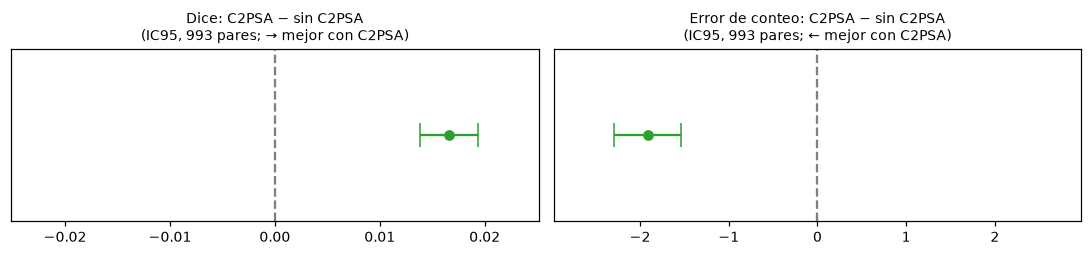

Los dos intervalos quedan enteros a un lado del cero: con C2PSA el modelo segmenta algo mejor y se equivoca menos al contar.
En validación (93 imágenes) la misma comparación no se distinguía del ruido (reports/ablacion_val_exploratorio.json).


In [13]:
ab = json.load(open(RAIZ / "reports" / "ablacion_test.json", encoding="utf-8"))
lineas = ["| Métrica (test) | Con C2PSA | Sin C2PSA | Diferencia | ¿Confirmada? |", "|---|---|---|---|---|"]
for clave, nombre in (("caja_50_95", "mAP@0.5:0.95 caja"), ("mascara_50_95", "mAP@0.5:0.95 máscara")):
    c, s = ab["mAP"]["c2psa"][clave], ab["mAP"]["sin_c2psa"][clave]
    lineas.append(f"| {nombre} (3 semillas) | {c['media']:.4f} ± {c['desv']:.4f} | {s['media']:.4f} ± {s['desv']:.4f} | "
                  f"{c['media'] - s['media']:+.4f} | sin bootstrap (media de 3 semillas) |")
for clave, nombre in (("dice_union", "Dice de la unión"), ("error_conteo_absoluto", "Error de conteo (manzanas por foto)")):
    r = ab[clave]
    lineas.append(f"| {nombre} | | | {r['diferencia_media']:+.3f} (IC95 {r['ic95_lo']:+.3f} a {r['ic95_hi']:+.3f}) | "
                  f"{'**sí**' if r['confirmada'] else 'no'} |")
display(Markdown("\n".join(lineas)))

fig, ejes = plt.subplots(1, 2, figsize=(10, 2.4))
for ax, (clave, titulo, mejor) in zip(ejes, (("dice_union", "Dice: C2PSA − sin C2PSA", "→ mejor con C2PSA"),
                                            ("error_conteo_absoluto", "Error de conteo: C2PSA − sin C2PSA", "← mejor con C2PSA"))):
    r = ab[clave]
    ax.errorbar([r["diferencia_media"]], [0], xerr=[[r["diferencia_media"] - r["ic95_lo"]], [r["ic95_hi"] - r["diferencia_media"]]],
                fmt="o", color="tab:green", capsize=8)
    ax.axvline(0, color="gray", ls="--")
    ax.set_yticks([])
    ax.set_title(f"{titulo}\n(IC95, {r['n_diferencias']} pares; {mejor})", fontsize=9)
    lim = 1.3 * max(abs(r["ic95_lo"]), abs(r["ic95_hi"]))
    ax.set_xlim(-lim, lim)
plt.tight_layout()
plt.show()
print("Los dos intervalos quedan enteros a un lado del cero: con C2PSA el modelo segmenta algo mejor y se equivoca menos al contar.")
print("En validación (93 imágenes) la misma comparación no se distinguía del ruido (reports/ablacion_val_exploratorio.json).")

## e. Aislamiento por instancia y Grad-CAM a mano
Con el **modelo final** (`colab_1280_small_s0`, small + C2PSA, 1280 px) sobre una imagen real de validación: `app/medidas.py` aísla cada
manzana con fondo transparente y mide su diámetro y color descriptivo; `app/gradcam.py` calcula Grad-CAM a mano sobre la capa 16 (elegida por el mayor cociente de enfoque sobre las manzanas, en
un barrido de 3 capas candidatas y 20 imágenes de validación con el modelo nano) y mide cuánta de la atención cae
dentro de las manzanas. Es la misma imagen y el mismo umbral (confianza 0,35) que usa la app en producción.


In [14]:
import sys as _sys
_sys.path.insert(0, str(RAIZ / "app"))
from analisis import cargar_imagen  # noqa: E402
from gradcam import enfoque, grad_cam, superponer  # noqa: E402
from medidas import medir  # noqa: E402
from ultralytics import YOLO

DISPOSITIVO = "cpu"  # reproducible sin depender de si la GPU está libre; la app sí usa GPU cuando hay una disponible
modelo = YOLO(str(RAIZ / "runs" / "colab_1280_small_s0" / "weights" / "best.pt"))
ruta_e = sorted((RAIZ / "data" / "yolo" / "images" / "val").glob("*.png"))[3]
img_e = cargar_imagen(ruta_e.read_bytes())
r_e = modelo.predict(img_e, imgsz=1280, conf=0.35, iou=0.7, max_det=300, retina_masks=True, device=DISPOSITIVO, verbose=False)[0]
masks_e = [] if r_e.masks is None else r_e.masks.data.cpu().numpy().astype(bool)
print(f"{ruta_e.name}: {len(masks_e)} manzanas detectadas (confianza 0,35, el umbral de la app)")


20150921_131234_image201.png: 40 manzanas detectadas (confianza 0,35, el umbral de la app)


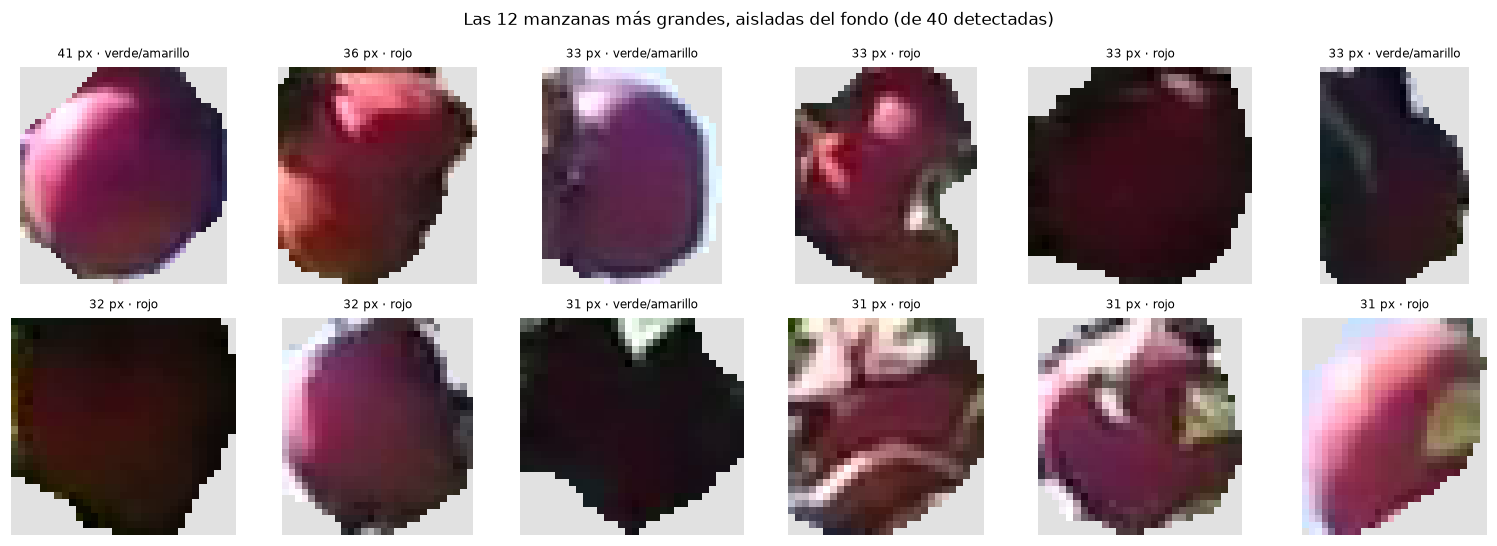

Diámetros (px) de las mostradas: [41, 36, 33, 33, 33, 33, 32, 32, 31, 31, 31, 31]


In [15]:
instancias = sorted((medir(img_e, m) for m in masks_e), key=lambda d: -d["area_px"])[:12]

fig, ejes = plt.subplots(2, 6, figsize=(14, 5))
for ax, d in zip(ejes.ravel(), instancias):
    alfa = d["recorte_bgra"][..., 3:4] / 255.0
    fondo_gris = (cv2.cvtColor(d["recorte_bgra"][..., :3], cv2.COLOR_BGR2RGB) * alfa + 225 * (1 - alfa)).astype("uint8")
    ax.imshow(fondo_gris)
    ax.set_title(f"{d['diametro_px']:.0f} px · {d['color']}", fontsize=8)
    ax.axis("off")
for ax in ejes.ravel()[len(instancias):]:
    ax.axis("off")
plt.suptitle(f"Las {len(instancias)} manzanas más grandes, aisladas del fondo (de {len(masks_e)} detectadas)")
plt.tight_layout()
plt.show()
print("Diámetros (px) de las mostradas:", [round(d["diametro_px"]) for d in instancias])

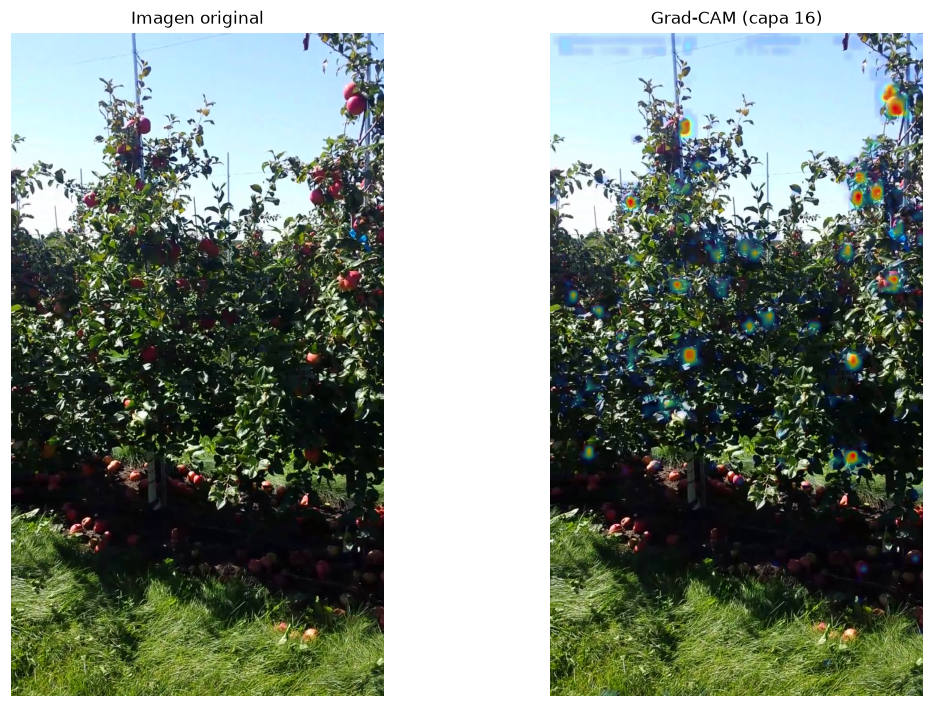

224 anclas con confianza ≥ 0,35 · las manzanas detectadas ocupan el 2.4% de la imagen y reciben el 48% de la atención del mapa (20 veces lo esperado al azar).
Esto coincide con el criterio que decidió la capa (cociente medio 54,0 sobre 20 imágenes de validación).


In [16]:
net_e = modelo.model.float().to(DISPOSITIVO).eval()
cam_e, n_anclas = grad_cam(net_e, img_e, capa=16, conf=0.35)
superpuesta = superponer(img_e, cam_e)
union_e = np.zeros(img_e.shape[:2], bool)
for m in masks_e:
    union_e |= m
dentro, area, cociente = enfoque(cam_e, union_e)

fig, ejes = plt.subplots(1, 2, figsize=(11, 6.5))
ejes[0].imshow(cv2.cvtColor(img_e, cv2.COLOR_BGR2RGB))
ejes[0].set_title("Imagen original")
ejes[1].imshow(cv2.cvtColor(superpuesta, cv2.COLOR_BGR2RGB))
ejes[1].set_title("Grad-CAM (capa 16)")
for ax in ejes:
    ax.axis("off")
plt.tight_layout()
plt.show()
print(f"{n_anclas} anclas con confianza ≥ 0,35 · las manzanas detectadas ocupan el {area:.1%} de la imagen y reciben el "
      f"{dentro:.0%} de la atención del mapa ({cociente:.0f} veces lo esperado al azar).")
assert cam_e.max() == 1.0 and cociente > 1, "el mapa debería concentrarse en las manzanas detectadas"
print("Esto coincide con el criterio que decidió la capa (cociente medio 54,0 sobre 20 imágenes de validación).")

### Grad-CAM con y sin self-attention (C2PSA)
Con el par exacto de la ablación (`c2psa_s0` y `sin_c2psa_s0`: nano, 1024 px, misma semilla, mismos datos — solo cambia la capa 10, `C2PSA`
o `nn.Identity`), se calcula Grad-CAM en la **misma imagen**, la misma capa (16) y el mismo umbral, para ver si la atención cambia
**dónde mira** el modelo, no solo cuánto acierta.

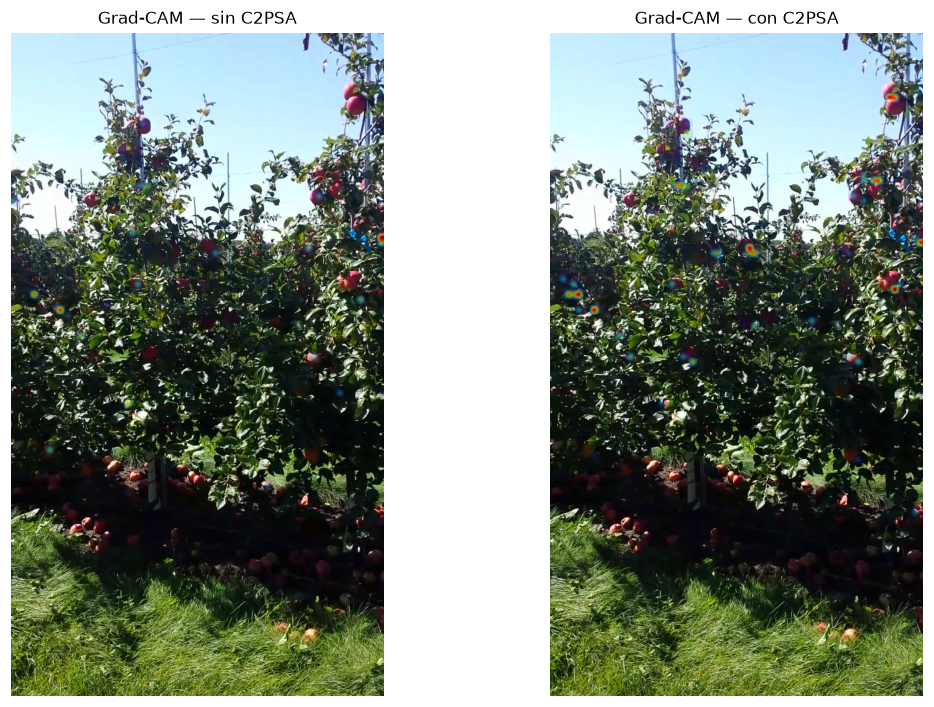

In [17]:
modelo_sin = YOLO(str(RAIZ / "runs" / "sin_c2psa_s0" / "weights" / "best.pt"))
modelo_con = YOLO(str(RAIZ / "runs" / "c2psa_s0" / "weights" / "best.pt"))

comparacion = {}
for etiqueta, m in (("sin C2PSA", modelo_sin), ("con C2PSA", modelo_con)):
    net = m.model.float().to(DISPOSITIVO).eval()
    cam, n_anclas = grad_cam(net, img_e, capa=16, conf=0.35, imgsz=1024)
    r = m.predict(img_e, imgsz=1024, conf=0.35, iou=0.7, max_det=300, retina_masks=True, device=DISPOSITIVO, verbose=False)[0]
    n_manzanas = 0 if r.masks is None else len(r.masks)
    masks = np.zeros(img_e.shape[:2], bool) if r.masks is None else r.masks.data.cpu().numpy().astype(bool).any(0)
    dentro, area, cociente = enfoque(cam, masks)
    comparacion[etiqueta] = {"superpuesta": superponer(img_e, cam), "n_manzanas": n_manzanas, "n_anclas": n_anclas,
                             "dentro": dentro, "area": area, "cociente": cociente}

fig, ejes = plt.subplots(1, 2, figsize=(11, 6.5))
for ax, etiqueta in zip(ejes, ("sin C2PSA", "con C2PSA")):
    ax.imshow(cv2.cvtColor(comparacion[etiqueta]["superpuesta"], cv2.COLOR_BGR2RGB))
    ax.set_title(f"Grad-CAM — {etiqueta}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## f. INT8 frente a FP32 y tiempos CPU frente a GPU
**Optimización:** el modelo final se exporta a ONNX (forma fija 1280×1280; tiene que ser cuadrada porque Ultralytics no calcula
el mAP de un ONNX exportado con forma rectangular) y se cuantiza a
**INT8 estático** con ONNX Runtime (QDQ, por canal, calibrado con 100 imágenes de train). Se compara **ONNX FP32 frente a ONNX INT8 en el
mismo motor**. **Tolerancia fijada antes de medir:** en validación, la caída de mAP@0.5:0.95 de caja y de máscara no puede superar 0,02.
El intento A (todo en INT8) dio mAP 0: la salida mezcla coordenadas (0 a 1.280 px) y confianzas (0 a 1) en una sola escala de 8 bits, y las
confianzas quedaban en 0. El intento B deja la cabeza (capa 23) en FP32. Después, el test se evaluó **una sola vez**, solo para reportar.

In [18]:
opt = json.load(open(RAIZ / "reports" / "optimizacion_colab_1280_small_s0_sincabeza.json", encoding="utf-8"))
mb = opt["tamano_mb"]
ev = lambda n: json.load(open(RAIZ / "reports" / "eval" / f"{n}.json", encoding="utf-8"))  # noqa: E731
filas_f = [("ONNX FP32", "final_onnx_fp32", mb["onnx_fp32"]), ("INT8, intento A (todo)", "final_onnx_int8", None),
           ("INT8, intento B (cabeza en FP32)", "final_onnx_int8_sincabeza", mb["onnx_int8"])]
lineas = ["| Modelo | Tamaño | Caja val | Máscara val | Caja test | Máscara test | Conteo test (sesgo) |", "|---|---|---|---|---|---|---|"]
for nombre, archivo, tam in filas_f:
    v = ev(f"{archivo}_val")
    t = ev(f"{archivo}_test") if (RAIZ / "reports" / "eval" / f"{archivo}_test.json").exists() else None
    celdas_t = (f"{t['caja']['mAP50-95']:.4f} | {t['mascara']['mAP50-95']:.4f} | {t['por_umbral']['0.35']['conteo_sesgo']:+.1f}"
                if t else "no se evaluó (descartado en val) | | ")
    lineas.append(f"| {nombre} | {f'{tam:.2f} MB' if tam else '—'} | {v['caja']['mAP50-95']:.4f} | {v['mascara']['mAP50-95']:.4f} | {celdas_t} |")
display(Markdown("\n".join(lineas)))

v32, v8 = ev("final_onnx_fp32_val"), ev("final_onnx_int8_sincabeza_val")
t32, t8 = ev("final_onnx_fp32_test"), ev("final_onnx_int8_sincabeza_test")
for part, a, b in (("validación", v32, v8), ("test", t32, t8)):
    dc, dm = b["caja"]["mAP50-95"] - a["caja"]["mAP50-95"], b["mascara"]["mAP50-95"] - a["mascara"]["mAP50-95"]
    print(f"INT8 (B) − FP32 en {part:10s}: caja {dc:+.4f}, máscara {dm:+.4f}  ->  "
          f"{'dentro' if min(dc, dm) >= -0.02 else 'FUERA'} de la tolerancia de −0,02")
print(f"Tamaño: {mb['onnx_fp32']:.2f} MB -> {mb['onnx_int8']:.2f} MB ({-opt['reduccion_int8_vs_fp32']:+.1%}). "
      f"El .pt ({mb['pt']:.2f} MB) está en FP16, por eso no es la referencia.")

| Modelo | Tamaño | Caja val | Máscara val | Caja test | Máscara test | Conteo test (sesgo) |
|---|---|---|---|---|---|---|
| ONNX FP32 | 39.16 MB | 0.4612 | 0.3643 | 0.4821 | 0.3472 | -0.8 |
| INT8, intento A (todo) | — | 0.0000 | 0.0000 | no se evaluó (descartado en val) | |  |
| INT8, intento B (cabeza en FP32) | 14.93 MB | 0.4447 | 0.3532 | 0.4379 | 0.3223 | +8.7 |

INT8 (B) − FP32 en validación: caja -0.0165, máscara -0.0112  ->  dentro de la tolerancia de −0,02
INT8 (B) − FP32 en test      : caja -0.0443, máscara -0.0249  ->  FUERA de la tolerancia de −0,02
Tamaño: 39.16 MB -> 14.93 MB (-61.9%). El .pt (19.62 MB) está en FP16, por eso no es la referencia.


**Lectura:** el INT8 se **aceptó en validación** (cumplía la tolerancia), pero en **test la supera**. Para ver de dónde sale la caída,
`scripts/comparar_int8.py` compara INT8 y FP32 imagen por imagen (bootstrap pareado, 10.000 remuestras) y por conjunto de fotos del test.
Según el criterio fijado antes, este resultado **solo se reporta**: no se prueba otra variante mirando el test, y la app no se afecta
(usa el `.pt`, que necesita gradientes para Grad-CAM).

| INT8 − FP32 (bootstrap pareado, IC95) | Validación (93) | Test (331) |
|---|---|---|
| Dice de la unión | -0.002 (-0.006 a +0.003) | -0.041 (-0.047 a -0.035) |
| Manzanas predichas de más por foto | +2.473 (+1.914 a +3.043) | +9.511 (+8.520 a +10.526) |
| Error de conteo (manzanas por foto) | -0.473 (-0.989 a +0.022) | +6.133 (+5.042 a +7.236) |

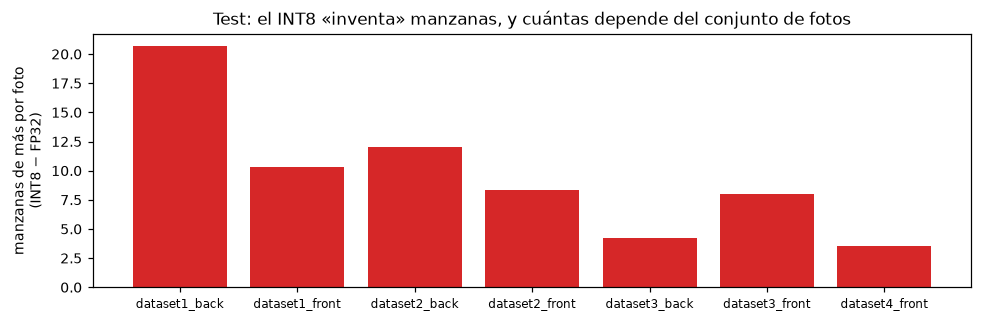

En validación el INT8 añadía unas 2,5 manzanas por foto; en test, 9,5. Explicación probable (no verificada): las fotos de calibración
(train) comparten videos con validación, pero no con el test oficial, que se grabó en otras hileras y otro año.


In [19]:
comp = {p: json.load(open(RAIZ / "reports" / f"int8_vs_fp32_{p}.json", encoding="utf-8")) for p in ("val", "test")}
lineas = ["| INT8 − FP32 (bootstrap pareado, IC95) | Validación (93) | Test (331) |", "|---|---|---|"]
for clave, nombre in (("dice", "Dice de la unión"), ("manzanas_de_mas", "Manzanas predichas de más por foto"),
                      ("error_conteo_abs", "Error de conteo (manzanas por foto)")):
    celdas = [f"{comp[p]['metricas'][clave]['media']:+.3f} ({comp[p]['metricas'][clave]['ic95'][0]:+.3f} a "
              f"{comp[p]['metricas'][clave]['ic95'][1]:+.3f})" for p in ("val", "test")]
    lineas.append(f"| {nombre} | {celdas[0]} | {celdas[1]} |")
display(Markdown("\n".join(lineas)))

grupos = comp["test"]["por_conjunto"]
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(list(grupos), [g["manzanas_de_mas"] for g in grupos.values()], color="tab:red")
ax.set_ylabel("manzanas de más por foto\n(INT8 − FP32)")
ax.set_title("Test: el INT8 «inventa» manzanas, y cuántas depende del conjunto de fotos")
ax.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.show()
print("En validación el INT8 añadía unas 2,5 manzanas por foto; en test, 9,5. Explicación probable (no verificada): las fotos de calibración")
print("(train) comparten videos con validación, pero no con el test oficial, que se grabó en otras hileras y otro año.")

### Tiempos de inferencia
Protocolo: calentamiento, **50 mediciones por caso** (mediana y p95), `cuda.synchronize()` en la GPU, casos intercalados en
orden aleatorio, 4 hilos en CPU y el hardware exacto en cada fila (`reports/benchmark.csv`, escrito por `scripts/benchmark.py`, que se
niega a medir si la CPU o la GPU están ocupadas). Etapas: **forward** (la red sola, entrada 1×3×1280×1280), **pipeline** (preproceso +
red + NMS + máscaras, cada motor con su forma nativa) y **app** (lo que hace la app con una foto, con y sin Grad-CAM).

Método v2 · 2026-09-27 · modelo colab_1280_small_s0 · torch 2.6.0+cu124 · onnxruntime 1.30.0
CPU: Intel(R) Core(TM) i5-8300H CPU @ 2.30GHz · GPU: NVIDIA GeForce GTX 1050


| Etapa | Formato | Dispositivo | Entrada | Mediana (ms) | p95 (ms) |
|---|---|---|---|---|---|
| forward | onnx-fp32 | CPU | 1x3x1280x1280 | 813 | 2285 |
| forward | onnx-int8 | CPU | 1x3x1280x1280 | 659 | 1178 |
| forward | pt | CPU | 1x3x1280x1280 | 846 | 1489 |
| forward | pt | GPU | 1x3x1280x1280 | 120 | 214 |
| pipeline | onnx-fp32 | CPU | 1280x1280 | 993 | 1076 |
| pipeline | onnx-int8 | CPU | 1280x1280 | 826 | 901 |
| pipeline | pt | CPU | auto (1280x736) | 480 | 561 |
| pipeline | pt | GPU | auto (1280x736) | 101 | 148 |
| app | pt | CPU | auto (1280x736) | 990 | 1175 |
| app | pt | GPU | auto (1280x736) | 323 | 371 |
| app+gradcam | pt | CPU | auto (1280x736) | 1530 | 3011 |
| app+gradcam | pt | GPU | auto (1280x736) | 923 | 1047 |

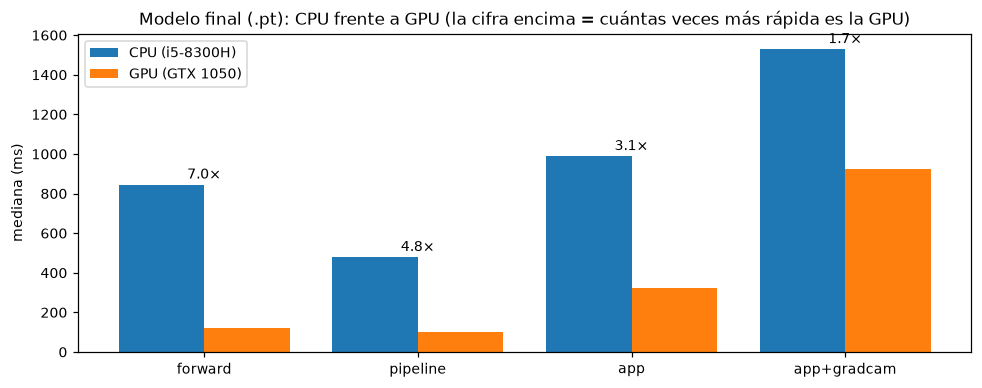

ONNX en CPU, forward : FP32 813 ms, INT8 659 ms -> INT8 1.23× más rápido
ONNX en CPU, pipeline: FP32 993 ms, INT8 826 ms -> INT8 1.20× más rápido


In [20]:
bench = list(csv.DictReader(open(RAIZ / "reports" / "benchmark.csv", encoding="utf-8")))
print(f"Método {bench[0]['metodo']} · {bench[0]['fecha']} · modelo {bench[0]['modelo']} · torch {bench[0]['torch']} · onnxruntime {bench[0]['onnxruntime']}")
print("CPU:", next(f["hardware"] for f in bench if f["dispositivo"] == "cpu"), "· GPU:", next(f["hardware"] for f in bench if f["dispositivo"] == "gpu"))
orden = {"forward": 0, "pipeline": 1, "app": 2, "app+gradcam": 3}
lineas = ["| Etapa | Formato | Dispositivo | Entrada | Mediana (ms) | p95 (ms) |", "|---|---|---|---|---|---|"]
for f in sorted(bench, key=lambda f: (orden[f["etapa"]], f["dispositivo"], f["formato"])):
    lineas.append(f"| {f['etapa']} | {f['formato']} | {f['dispositivo'].upper()} | {f['forma_entrada']} | {float(f['mediana_ms']):.0f} | {float(f['p95_ms']):.0f} |")
display(Markdown("\n".join(lineas)))

med = {(f["etapa"], f["formato"], f["dispositivo"]): float(f["mediana_ms"]) for f in bench}
etapas = ["forward", "pipeline", "app", "app+gradcam"]
x = np.arange(len(etapas))
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(x - 0.2, [med[(e, "pt", "cpu")] for e in etapas], 0.4, label="CPU (i5-8300H)", color="tab:blue")
ax.bar(x + 0.2, [med[(e, "pt", "gpu")] for e in etapas], 0.4, label="GPU (GTX 1050)", color="tab:orange")
for xi, e in zip(x, etapas):
    ax.text(xi, med[(e, "pt", "cpu")] + 30, f"{med[(e, 'pt', 'cpu')] / med[(e, 'pt', 'gpu')]:.1f}×", ha="center", fontsize=9)
ax.set_xticks(x, etapas)
ax.set_ylabel("mediana (ms)")
ax.set_title("Modelo final (.pt): CPU frente a GPU (la cifra encima = cuántas veces más rápida es la GPU)")
ax.legend()
plt.tight_layout()
plt.show()
for etapa in ("forward", "pipeline"):
    a, b = med[(etapa, "onnx-fp32", "cpu")], med[(etapa, "onnx-int8", "cpu")]
    print(f"ONNX en CPU, {etapa:8s}: FP32 {a:.0f} ms, INT8 {b:.0f} ms -> INT8 {a / b:.2f}× más rápido")

**Lectura:** la GPU es **7 veces más rápida** en la red sola y 3 veces en la app completa (323 ms frente a 990 ms por foto); las dos
sirven para la demo. El INT8 gana sobre todo en **tamaño** (−62 %); en velocidad solo un **20 %** en esta CPU (razones probables, no
perfiladas: la cabeza sigue en FP32 y el i5-8300H no tiene instrucciones VNNI para enteros de 8 bits). El pipeline ONNX es más lento que el
del `.pt` porque procesa un cuadrado de 1280×1280 (1,74 veces más píxeles que el rectángulo de 1280×736 que usa el `.pt`). Algunos p95 de CPU
son altos: la frecuencia de un portátil varía; la mediana es la cifra de referencia.